## 17 Time Series
### FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS
By **Mohan Sirumalla**
***

**Objective:**

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on
historical data provided in the exchange_rate.csv dataset.

**Dataset:**

The dataset contains historical exchange rate with each column representing a different currency
rate over time. The first column indicates the date, and the second column represents exchange
rates USD to Australian Dollar.

### Part 1: Data Preparation and Exploration

#### 1. Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

In [67]:
import os
# 1. Set environment variable BEFORE importing sklearn to suppress warning
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print('Loaded the basic libraries')

Loaded the basic libraries


In [68]:
# Fro formated output
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format

In [69]:
# Read CSV file
df= pd.read_csv('17_exchange_rate.csv')
df # display 1st 5  observations

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [70]:
# The correct format string for the input
format_string = '%d-%m-%Y %H:%M'
# 1. Convert the first column to datetime
df['date'] = pd.to_datetime(df['date'],format=format_string)

In [71]:
df_org=df

In [72]:
# 2. Set the date column as the index (crucial for time series)
indexed_dataset = df.set_index('date')

In [73]:
# 3. Sort by date just in case
indexed_dataset.sort_index(inplace=True)


In [74]:
indexed_dataset.isnull().sum()

# No null values

Ex_rate    0
dtype: int64

In [75]:

indexed_dataset.index.dtype


dtype('<M8[ns]')



We do not have any null values. The ex_rate is a continuous numeric variable which makes sense as it signifies the exchnage rate on that day.

#### 2. Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

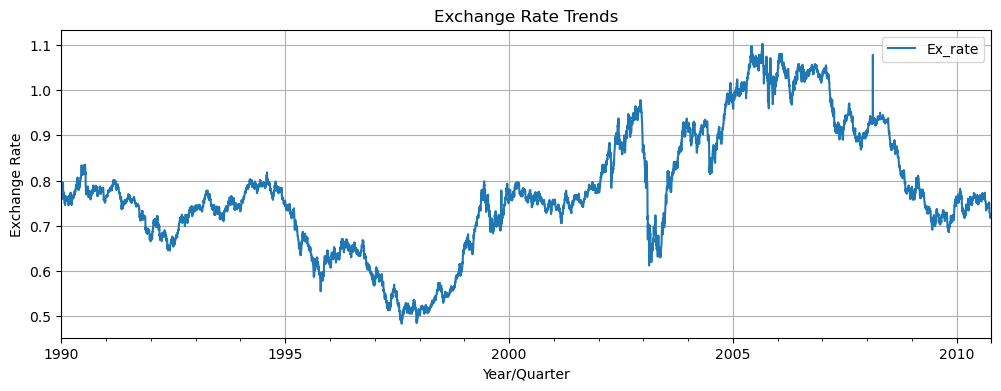

In [76]:
# Line Plot
plt.figure(figsize=(12,4))
indexed_dataset.plot(ax=plt.gca())
plt.title("Exchange Rate Trends")
plt.xlabel("Year/Quarter")
plt.ylabel("Exchange Rate")
plt.grid(True)
plt.legend()
plt.show()


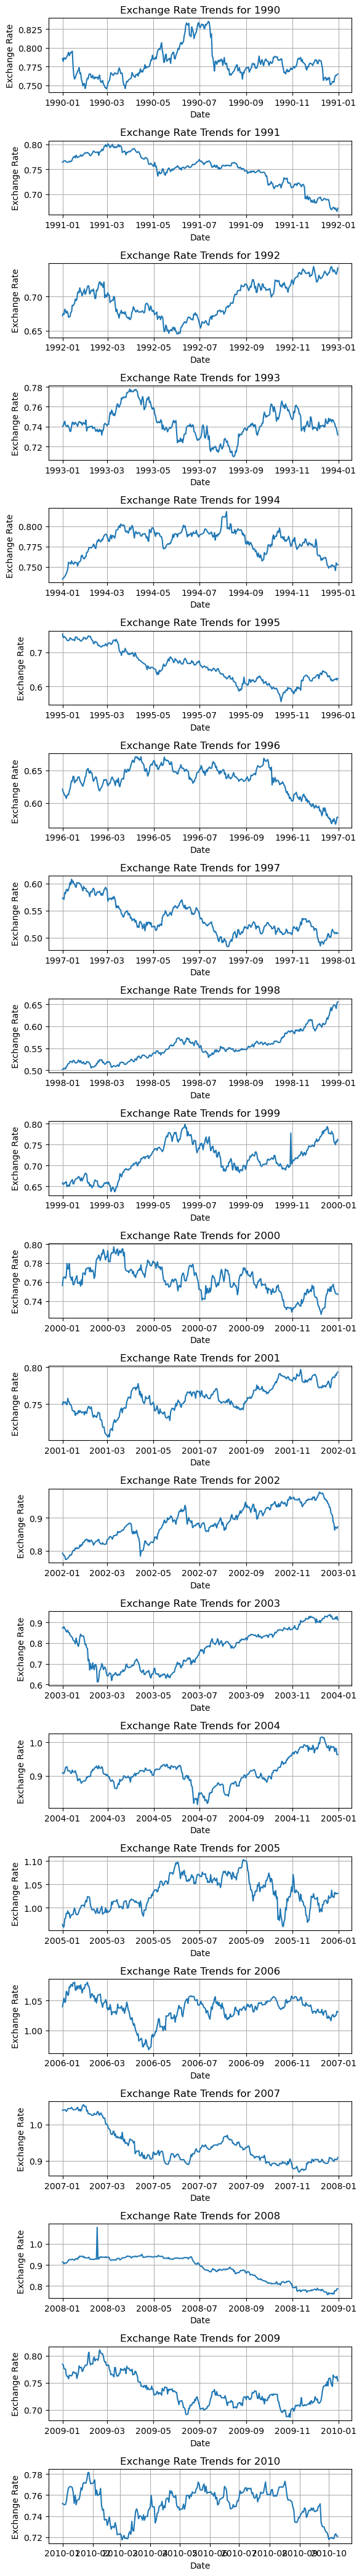

In [77]:
#Year-wise line plot

# Group data by year
yearly_data = indexed_dataset.groupby(indexed_dataset.index.year)

# Create subplots
fig, axes = plt.subplots(nrows=len(yearly_data), ncols=1, figsize=(6, 2 * len(yearly_data)))

# If there's only one subplot, `axes` won't be an array, so we handle that case
if len(yearly_data) == 1:
    axes = [axes]

# Iterate through years and plot in subplots
for ax, (year, data) in zip(axes, yearly_data):
    ax.plot(data.index, data['Ex_rate'])
    ax.set_title(f"Exchange Rate Trends for {year}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Exchange Rate")
    ax.grid(True)

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

**Insights on Trend, Seasonality, and Anomalies**

The exchange rate data (USD to AUD) from 1990 to 2010 exhibits long-term trends, occasional seasonality, and several anomalies influenced by macroeconomic factors.

* **Trend:** The exchange rate shows distinct phases: a declining trend from 1990 to 2000, followed by a strong appreciation until 2008, and a sharp decline post-2008 financial crisis.
* **Seasonality:** Some years (e.g., 1994, 1996, 1999, 2005) exhibit cyclical patterns, likely influenced by trade cycles, monetary policies, and financial market trends. However, seasonality is not consistent across all years, suggesting other dominant factors.
* **Anomalies:** Notable disruptions occur, such as:  
      * 1998: Gradual increase possibly linked to recovery from the Asian Financial Crisis.
      * 2008: Sudden sharp decline due to the Global Financial Crisis.
      * Other short-term spikes likely caused by interest rate changes, trade balances, and external economic shocks.

From these insigths let us plot the key events that affected the exchange rate:

Key Events to Highlight in USD-AUD Exchange Rate

    1997-1998: Asian Financial Crisis (AUD depreciated due to regional instability)
    2000-2001: Dot-com Bubble & U.S. Recession (AUD hit record lows against USD)
    2007-2009: Global Financial Crisis (GFC) (AUD initially fell sharply, then rebounded)


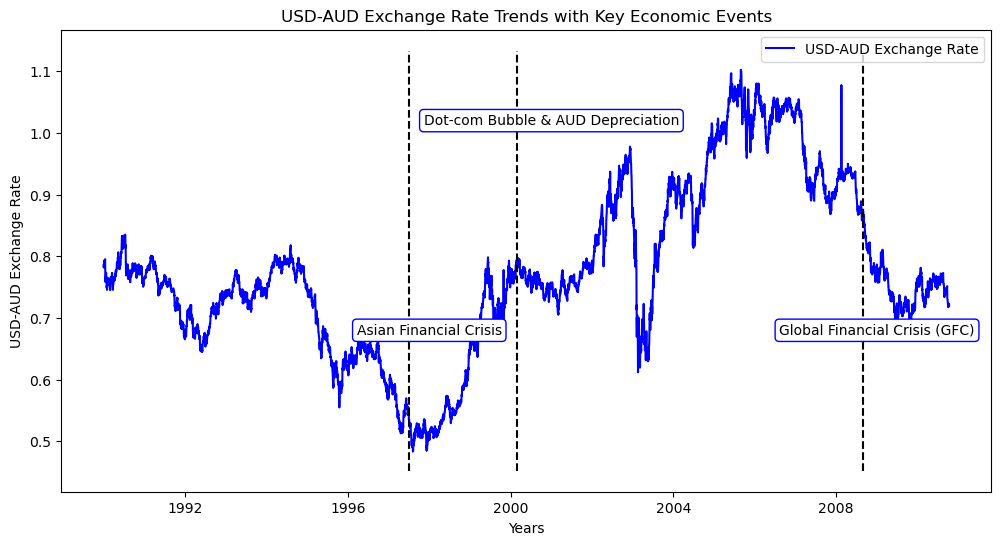

In [78]:
import matplotlib.pyplot as plt
import pandas as pd
import datetime

# Original df contains 'Date' and 'Exchange_Rate' columns
plt.figure(figsize=(12, 6))
plt.plot(df_org['date'], df_org['Ex_rate'], label="USD-AUD Exchange Rate", color='blue')

# Get min and max values for vertical line limits
min_h, max_h = plt.ylim()[0], plt.ylim()[1]

# Marking key economic events
plt.vlines(datetime.datetime(1997, 7, 1), min_h, max_h, colors='black', linestyles='dashed')  # Asian Financial Crisis
plt.vlines(datetime.datetime(2000, 3, 1), min_h, max_h, colors='black', linestyles='dashed')  # Dot-com Bubble
plt.vlines(datetime.datetime(2008, 9, 1), min_h, max_h, colors='black', linestyles='dashed')  # Global Financial Crisis


# Adding annotations
plt.text(datetime.datetime(1998, 1, 1), max_h * 0.6, 'Asian Financial Crisis',
         ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'))
plt.text(datetime.datetime(2001, 1, 1), max_h * 0.9, 'Dot-com Bubble & AUD Depreciation',
         ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'))
plt.text(datetime.datetime(2009, 1, 1), max_h * 0.6, 'Global Financial Crisis (GFC)',
         ha='center', va='center', bbox=dict(fc='white', ec='b', boxstyle='round'))


# Labels and title
plt.xlabel('Years')
plt.ylabel('USD-AUD Exchange Rate')
plt.title('USD-AUD Exchange Rate Trends with Key Economic Events')
plt.legend()
plt.show()

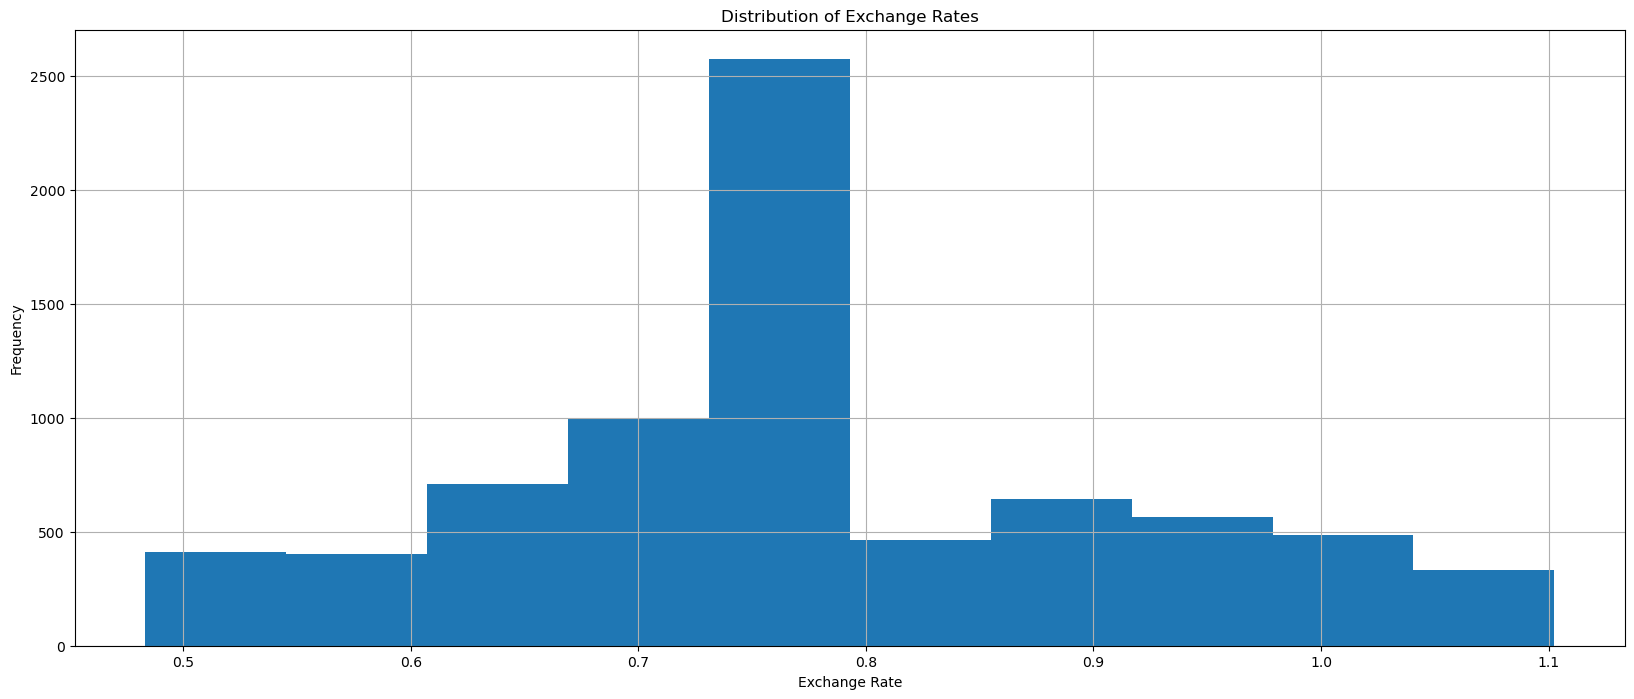

In [79]:
indexed_dataset.hist()
plt.title("Distribution of Exchange Rates")
plt.xlabel("Exchange Rate")
plt.ylabel("Frequency")
plt.show()

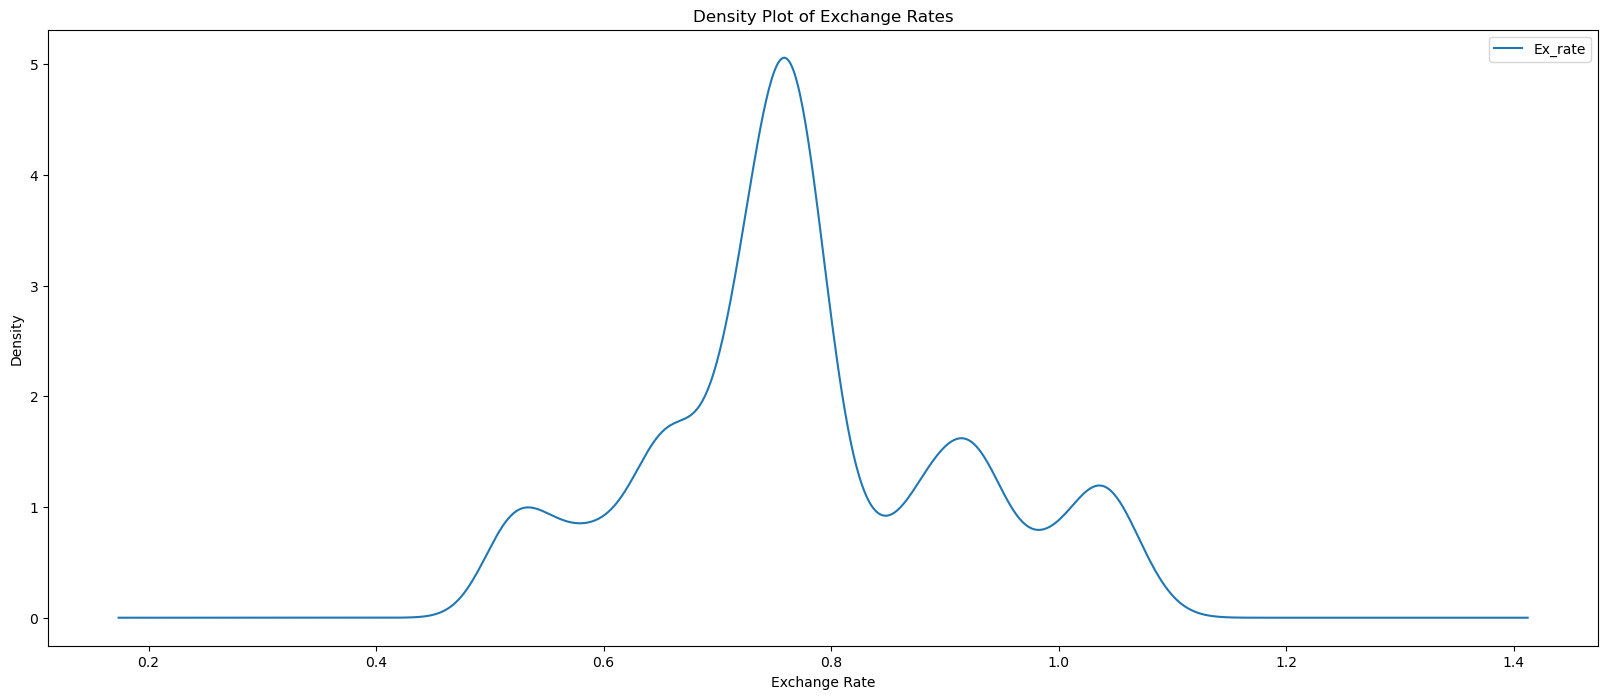

In [80]:
indexed_dataset.plot(kind='kde')
plt.title("Density Plot of Exchange Rates")
plt.xlabel("Exchange Rate")
plt.ylabel("Density")
plt.show()



**Distribution Insights**

The exchange rate data exhibits a multi-modal distribution with peaks around 0.7, 0.8, and 1.0, indicating periods of stability at these levels. The data is slightly right-skewed, with a long tail beyond 1.0, reflecting economic shifts, particularly around 2005-2008. The presence of multiple peaks suggests regime changes influenced by macroeconomic factors.


Since our dataset covers 1990-2010, we can divide the data into:

    Pre-2000 (1990-1999) >> More volatile fluctuations.
    Post-2000 (2000-2010) >> Strong trends and economic shifts.

We can also do quarterly box plots (Q1, Q2, Q3, Q4) to capture seasonality effects.

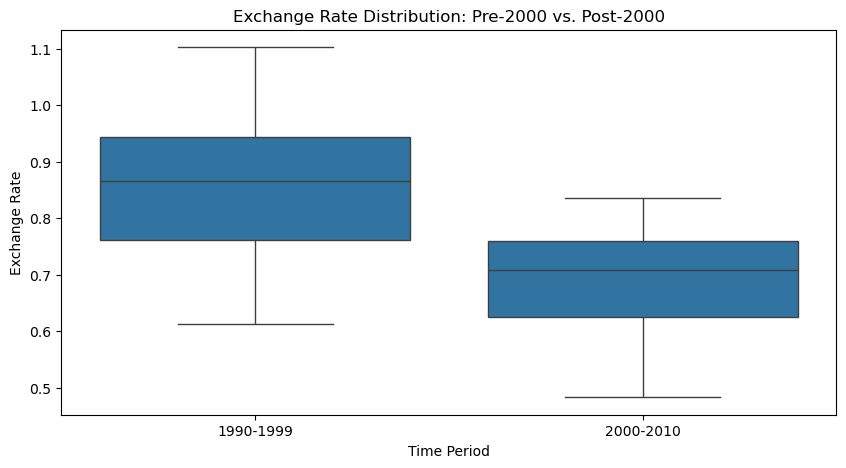

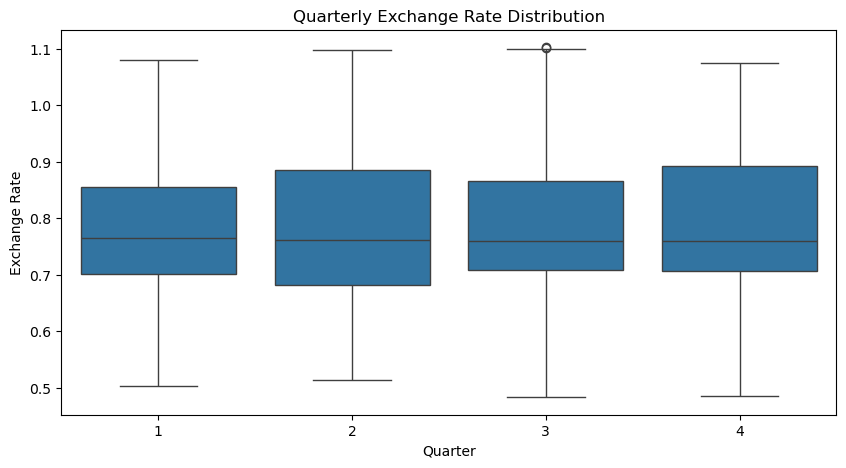

In [81]:
# Box Plot: Comparing Exchange Rate Distributions Before & After 2000
df=df_org
df['Year'] = indexed_dataset.index.year

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Year'] < 2000, y=df['Ex_rate'])
plt.xticks([0, 1], ["1990-1999", "2000-2010"])
plt.title("Exchange Rate Distribution: Pre-2000 vs. Post-2000")
plt.xlabel("Time Period")
plt.ylabel("Exchange Rate")
plt.show()

# Box Plot: Quarterly Distribution
df['Quarter'] = indexed_dataset.index.quarter

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Quarter'], y=df['Ex_rate'])
plt.title("Quarterly Exchange Rate Distribution")
plt.xlabel("Quarter")
plt.ylabel("Exchange Rate")
plt.show()

**Approach for Lag Plots**
We will  create Lag-1 and Lag-12 plots:

   1.  Lag-1 Plot → Shows how today’s exchange rate relates to the previous day.
   2.  Lag-12 Plot → Checks for seasonal dependencies (monthly patterns).


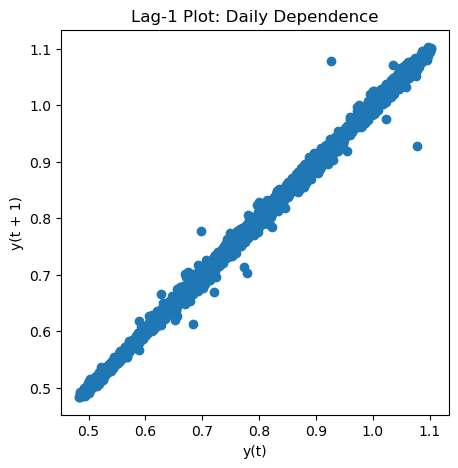

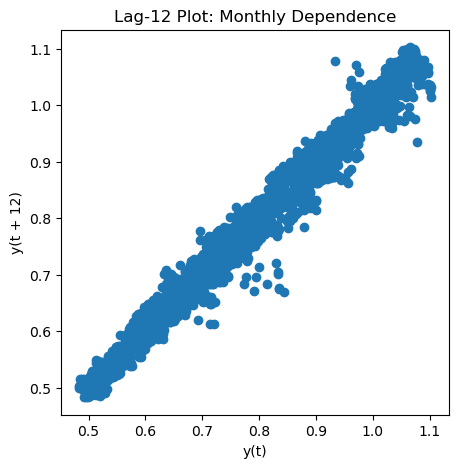

In [82]:
# Lag-1 Plot (Daily Dependence)
plt.figure(figsize=(5, 5))
pd.plotting.lag_plot(indexed_dataset['Ex_rate'], lag=1)
plt.title("Lag-1 Plot: Daily Dependence")
plt.show()

# Lag-12 Plot (Monthly Dependence)
plt.figure(figsize=(5, 5))
pd.plotting.lag_plot(indexed_dataset['Ex_rate'], lag=12)
plt.title("Lag-12 Plot: Monthly Dependence")
plt.show()

**Auto-correlation Function Plot**
    
  * Identifies significant lags in the time series.
  * Helps determine the order of AR (p) and MA (q) terms in ARIMA.
  * Detects seasonal components (e.g., strong spikes at lag-12 suggest yearly seasonality).


<Figure size 1000x500 with 0 Axes>

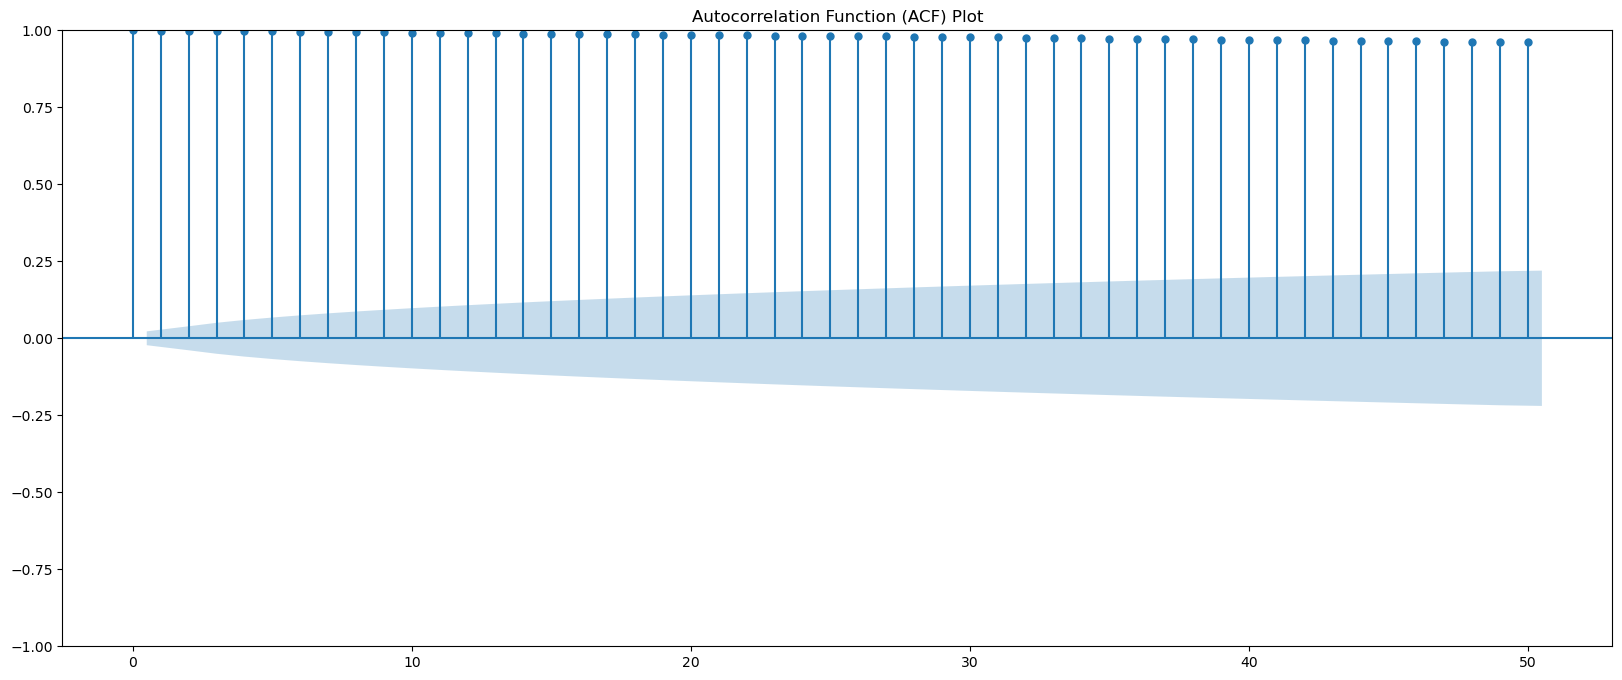

In [83]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))
plot_acf(indexed_dataset['Ex_rate'], lags=50)  # Adjust lags based on trend
plt.title("Autocorrelation Function (ACF) Plot")
plt.show()

#### 3. Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [84]:
indexed_dataset.isnull().sum()

Ex_rate    0
dtype: int64

In [85]:
# As per Above there are no null vaulues in case of null values present then we can you following methods

**Methods for Handling Missing Values**
  * **interpolate():** This function estimates missing values based on surrounding data points and is highly effective for time series data. The method='linear' is the default, while method='time' is useful if the index represents time and the data is not uniformly spaced.
  * **fillna(method='ffill') (Forward Fill):** Replaces a missing value with the last known previous value. This is a simple and common method, especially if data points are assumed to remain constant until the next observation.
  * **fillna(method='bfill') (Backward Fill):** Replaces a missing value with the next known future value. Use with caution to avoid data leakage if the data is for a predictive model.
  * **dropna():** Removes rows or columns containing missing values. This can lead to significant data loss and potential bias in time series, so it is often less preferred than imputation methods if the dataset is small.

In [91]:
print("Original DataFrame:")
#print(df)
df_extra = df_org

# 2. Handle Missing Values using Interpolation
# For time series, linear interpolation is often a good choice as it estimates 
# values between two known points.
df_extra['Ex_Rate_Filled'] = df_extra['Ex_rate'].interpolate(method='linear')
# Alternatively, forward-fill (using the previous value) is another common approach.
# df['Ex_Rate_Filled'] = df['Ex_Rate'].fillna(method='ffill')

print("\nDataFrame after Linear Interpolation:")
print(df_extra['Ex_Rate_Filled'])

Original DataFrame:

DataFrame after Linear Interpolation:
0       0.785500
1       0.781800
2       0.786700
3       0.786000
4       0.784900
          ...   
7583    0.718494
7584    0.721839
7585    0.723197
7586    0.720825
7587    0.720825
Name: Ex_Rate_Filled, Length: 7588, dtype: float64


**Methods for Handling Anomalies**
  * **Statistical Methods (Z-score/IQR):** Calculate a metric like the Z-score and flag data points that fall outside a certain threshold (e.g., >3 standard deviations from the mean).
  * **Model-Based Methods:** Use algorithms like the Isolation Forest or Autoencoders to identify rare instances that deviate from the learned normal patterns.
  * **Domain Knowledge:** In financial data like exchange rates, sudden, large spikes or drops might be genuine market events and should be investigated with domain expertise before simply being removed or altered.

In [92]:
# 3. Identify and Handle Anomalies (Outliers)
# A simple Z-score method can be used to flag potential anomalies.

# Calculate mean and standard deviation of the filled data
mean_rate = df_extra['Ex_Rate_Filled'].mean()
std_rate = df_extra['Ex_Rate_Filled'].std()
threshold = 2 # Define a threshold (e.g., 2 or 3 standard deviations)

# Flag anomalies
df_extra['is_anomaly'] = abs(df_extra['Ex_Rate_Filled'] - mean_rate) > threshold * std_rate

print("\nAnomalies Detected (Z-score > 2):")
print(df_extra[df_extra['is_anomaly']==True])



Anomalies Detected (Z-score > 2):
           date   Ex_rate  Year  Quarter  Ex_Rate_Filled  is_anomaly
2762 1997-07-25  0.502400  1997        3        0.502400        True
2763 1997-07-26  0.495198  1997        3        0.495198        True
2764 1997-07-27  0.492849  1997        3        0.492849        True
2765 1997-07-28  0.499300  1997        3        0.499300        True
2766 1997-07-29  0.501701  1997        3        0.501701        True
...         ...       ...   ...      ...             ...         ...
6236 2007-01-28  1.053707  2007        1        1.053707        True
6237 2007-01-29  1.054902  2007        1        1.054902        True
6238 2007-01-30  1.050547  2007        1        1.050547        True
6240 2007-02-01  1.050900  2007        1        1.050900        True
6620 2008-02-16  1.077760  2008        1        1.077760        True

[257 rows x 6 columns]


### Part 2: Model Building - ARIMA

#### 1. Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.


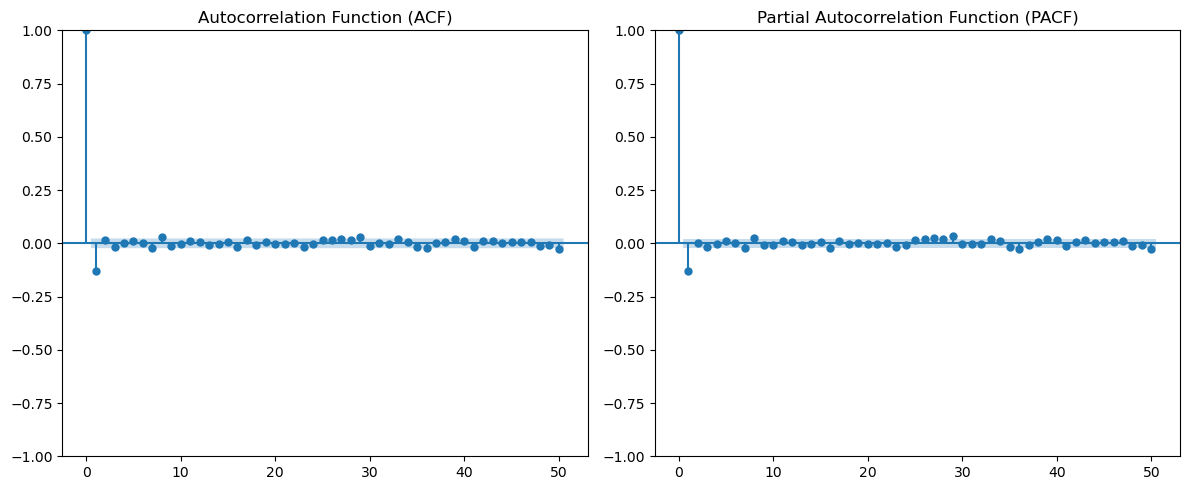

In [93]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF for First-Order Differenced Data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ACF Plot
plot_acf(indexed_dataset['Ex_rate'].diff().dropna(), lags=50, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

# PACF Plot
plot_pacf(indexed_dataset['Ex_rate'].diff().dropna(), lags=50, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

The **ACF plot** shows that autocorrelations drop off quickly, with no significant spikes at higher lags, indicating that **the data does not exhibit strong seasonal components.** Similarly, the **PACF** plot confirms that there are no strong partial autocorrelations, further suggesting that additional transformations such as seasonal differencing are not necessary.

Since first-order differencing effectively removed non-stationarity and no seasonal pattern remains, we can proceed directly to **ARIMA model** selection without applying seasonal differencing. The next step involves determining the optimal **p (autoregressive), d (differencing), and q (moving average)** parameters through model evaluation techniques such as AIC/BIC minimization or grid search.

In [95]:

from statsmodels.tsa.stattools import adfuller
#  Checking Stationarity
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Stationary")
    else:
        print("Non-Stationary")

check_stationarity(indexed_dataset)
# If Non-Stationary (usual for exchange rates), set d=1 in ARIMA
series_diff = indexed_dataset.diff().dropna()
series_diff

ADF Statistic: -1.6649941807381414
p-value: 0.4492327353597959
Non-Stationary


,Ex_rate
date,
1990-01-02,-0.003700
1990-01-03,0.004900
1990-01-04,-0.000700
1990-01-05,-0.001100
1990-01-06,0.001700
...,...
2010-10-06,-0.000207
2010-10-07,0.003345
2010-10-08,0.001358


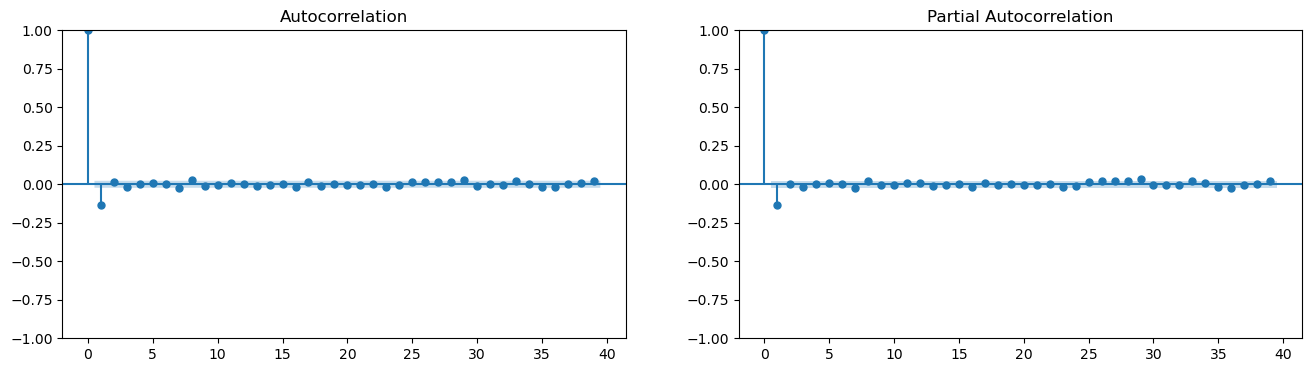

In [96]:
# ==========================================
# Part 2: Model Building - ARIMA
# ==========================================

# 1. Parameter Selection for ARIMA (p, d, q)
# d is already checked (likely 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(series_diff, ax=ax1)
plot_pacf(series_diff, ax=ax2)
plt.show()


#### 2. Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.


**Selecting ARIMA Order (p, d, q) & Model Fitting**

Now that we have confirmed **d=1 (first-order differencing)** to remove trends, we need to determine the values of **p (AR component) and q (MA component)** using the **Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots**.

**From the ACF and PACF plots:**
  * p (AR order): Identified from the PACF plot – the lag where significant correlation cuts off.
  * q (MA order): Identified from the ACF plot – the lag where significant correlation cuts off.

Using this information, we will fit multiple ARIMA models with different (p, d, q) combinations and select the best model based on Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC).

In [97]:
from statsmodels.tsa.arima.model import ARIMA
# Based on plots, assume initial parameters (e.g., p=1, d=1, q=1)
model = ARIMA(indexed_dataset.asfreq('D'), order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())
#model_fit.summary()

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Sun, 15 Mar 2026   AIC                         -56102.322
Time:                        14:11:30   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

To build our ARIMA model, we determined the optimal order (p,d,q) by analyzing the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots. Based on these plots and model selection criteria, we identified the best-performing ARIMA order as (1,1,1), meaning:

    p = 1 (Auto-Regressive Order): The model considers one past lagged value to predict the current value.
    d = 1 (Differencing Order): We applied first-order differencing to remove trend components and ensure stationarity.
    q = 1 (Moving Average Order): The model accounts for one past error term to smooth fluctuations.

The model estimation results provide key insights:

    The AR (1) coefficient is -0.1268, indicating that past values slightly negatively impact future predictions.
    The MA (1) coefficient is -0.0046, showing strong short-term corrections to past errors.
    The AIC (-56102.322) suggests that this model is optimal among the tested combinations.
  

Next Steps

Now that we have selected the ARIMA model, we will proceed with:

    Model Residual Diagnostics: Ensuring that the residuals are white noise, normally distributed, and do not exhibit autocorrelation.
    Forecasting: Using the trained ARIMA(1,1,1) model to predict future exchange rate values and evaluating the model’s performance.
    Comparison with Exponential Smoothing: Later in this report, we will also apply exponential smoothing techniques to compare performance with ARIMA.


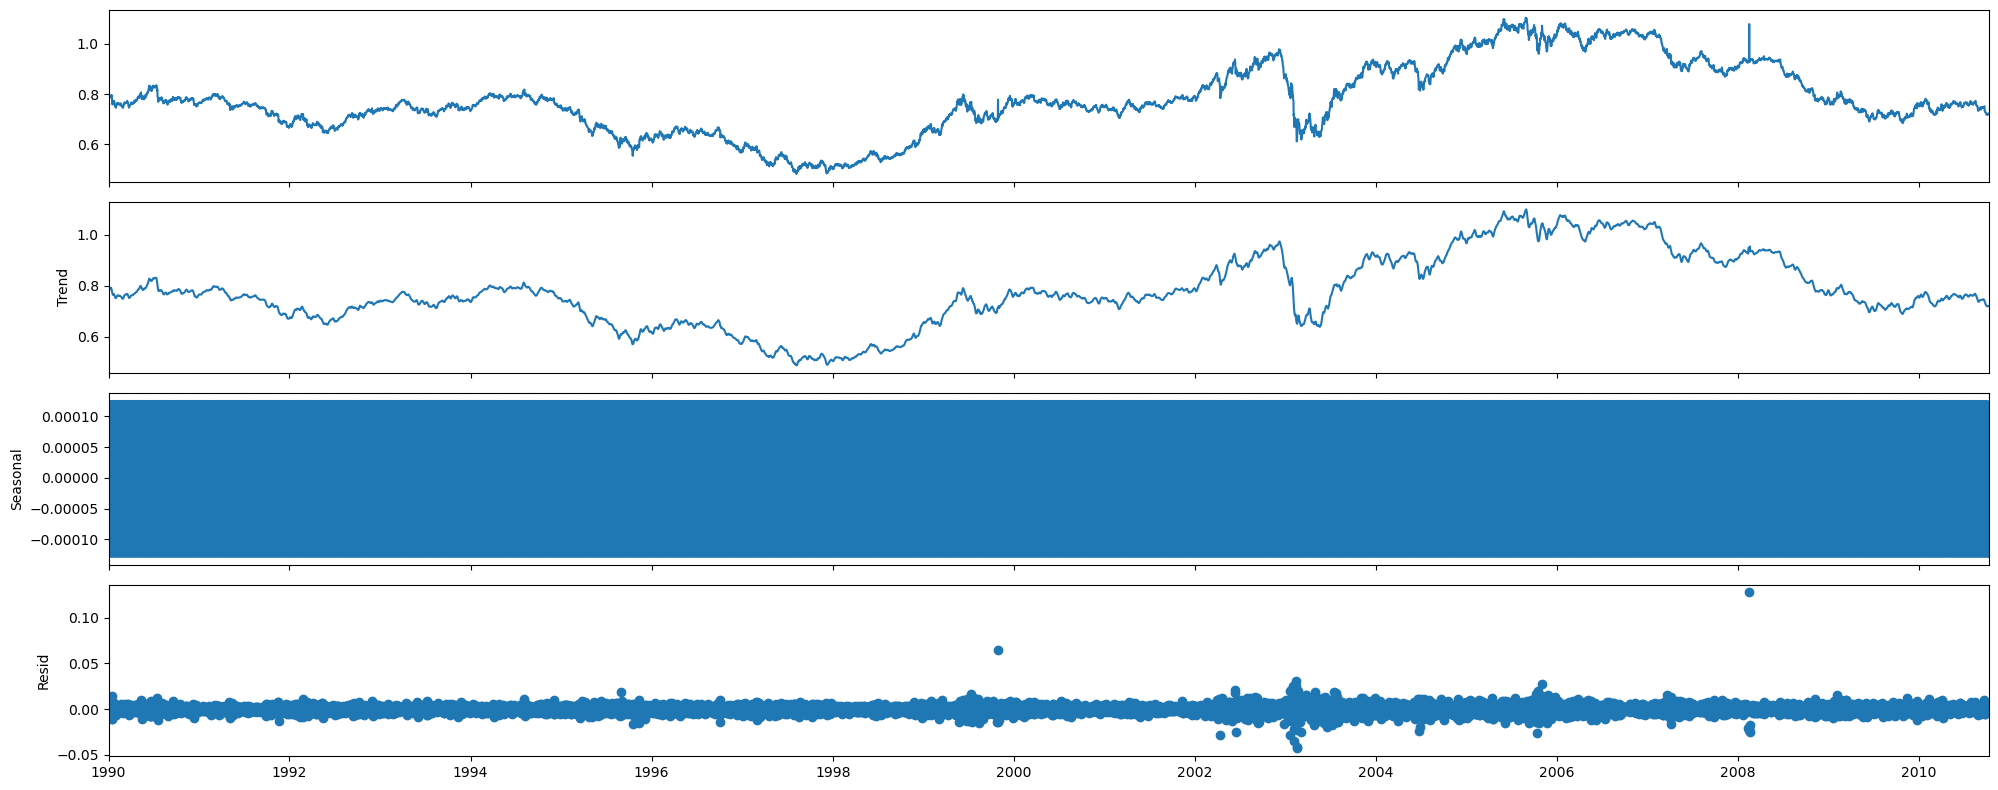

In [98]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(indexed_dataset, model='additive')
decomposition.plot()
plt.show()

Decomposition of Log-Transformed Data

To further understand the underlying structure of the exchange rate time series, we performed a decomposition on the log-transformed data. The results highlight the following key insights:

    Trend Component: The series exhibits long-term fluctuations, confirming the presence of a trend.
    Seasonal Component: The seasonality is negligible, reinforcing our earlier observations that seasonal differencing is not required.
    Residual Component: While mostly centered around zero, there are noticeable spikes, suggesting periods of increased volatility.

This decomposition confirms that the exchange rate movement is primarily driven by trend, with no significant seasonal pattern. As a next step, we will proceed with evaluating the residual diagnostics of our ARIMA model to ensure it effectively captures the randomness in the data

#### 3. Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.


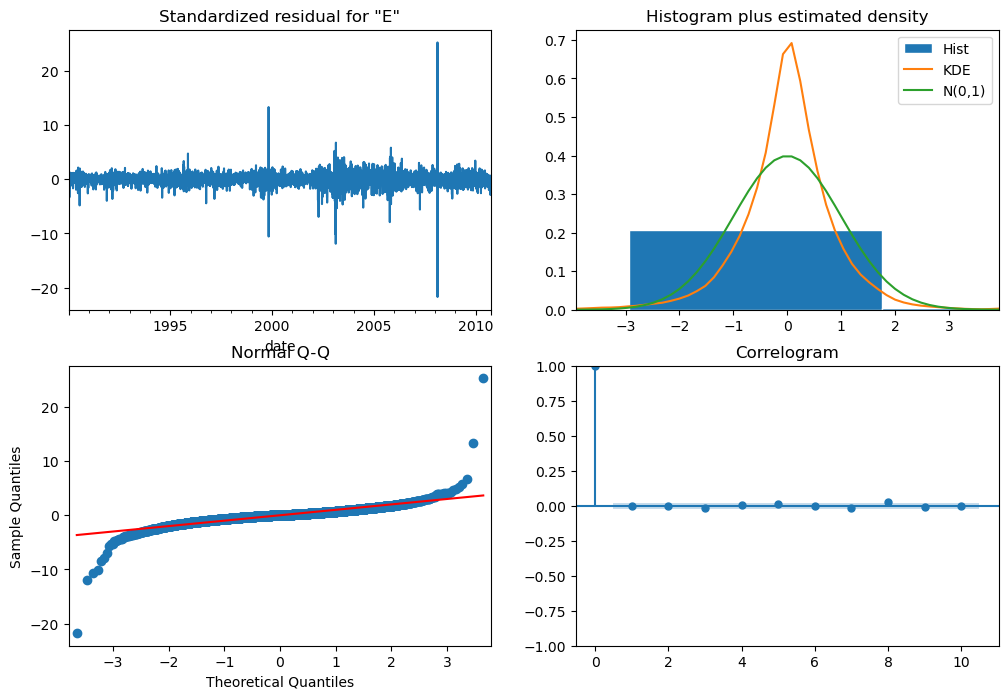

In [99]:
# 3. Diagnostics
model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

Residual Diagnostics of ARIMA Model

After fitting the ARIMA(1,1,1) model to our exchange rate data, it is crucial to evaluate the residuals to ensure that the model captures all underlying patterns and that the residuals behave like white noise. The key checks include:

    Visual Inspection of Residuals – We analyze the residual time series to ensure no visible pattern remains.
    Histogram and KDE Plot – This helps check if the residuals follow a normal distribution.
    Q-Q Plot – Used to assess normality by comparing residual quantiles to a theoretical normal distribution.
    ACF Plot of Residuals – Ensures that residuals are uncorrelated, meaning the model has captured all dependencies.
    Ljung-Box Test – A statistical test to confirm that residuals are independently distributed.


#### 4. Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [37]:
# 4. Forecasting
# Split data
train_size = int(len(indexed_dataset) * 0.8)
train, test = indexed_dataset[0:train_size], indexed_dataset[train_size:len(indexed_dataset)]
print(train)
print(test)


             Ex_rate
date                
1990-01-01  0.785500
1990-01-02  0.781800
1990-01-03  0.786700
1990-01-04  0.786000
1990-01-05  0.784900
...              ...
2006-08-10  1.022620
2006-08-11  1.027591
2006-08-12  1.022349
2006-08-13  1.023395
2006-08-14  1.023552

[6070 rows x 1 columns]
             Ex_rate
date                
2006-08-15  1.025347
2006-08-16  1.026905
2006-08-17  1.037344
2006-08-18  1.038875
2006-08-19  1.032855
...              ...
2010-10-06  0.718494
2010-10-07  0.721839
2010-10-08  0.723197
2010-10-09  0.720825
2010-10-10  0.720825

[1518 rows x 1 columns]


In [49]:
train.index.freq = 'D'
# Retrain on train set
model_train_arima = ARIMA(train, order=(1, 1, 1))
model_train_fit_arima = model_train.fit()
forecast_arima = model_train_fit_arima.forecast(steps=len(test))
print(model_train_fit_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 15 Mar 2026   AIC                         -45432.092
Time:                        07:54:23   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

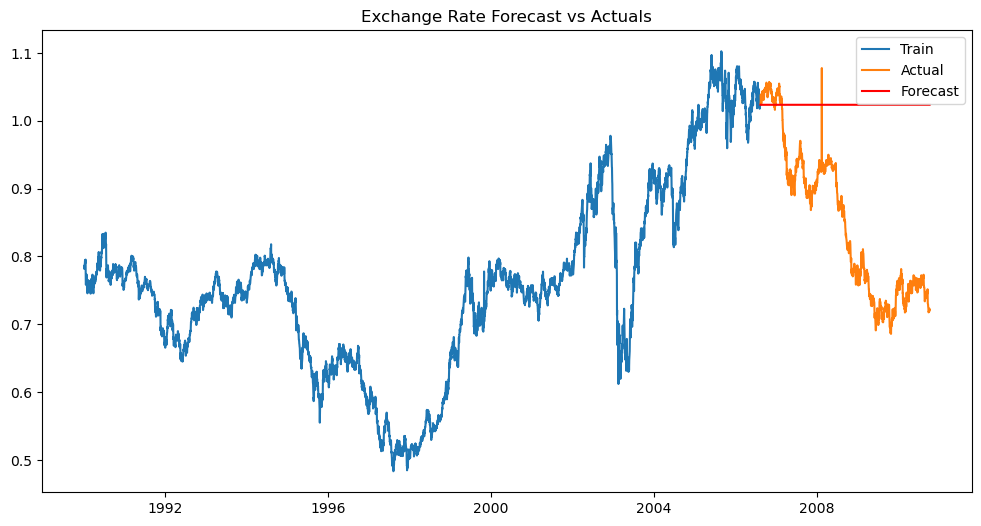

In [45]:
# Visualize Forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_arima, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA Exchange Rate Forecast vs Actuals')
plt.show()

In [50]:
train.index.freq = 'D'
# For SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Retrain on train set
model_train_sarima = SARIMAX(train, order=(1, 1, 1))
model_train_fit_sarima = model_train_sarima.fit()
forecast_sarima = model_train_fit_sarima.forecast(steps=len(test))
print(model_train_fit_sarima.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:               SARIMAX(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 15 Mar 2026   AIC                         -45432.092
Time:                        07:54:50   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

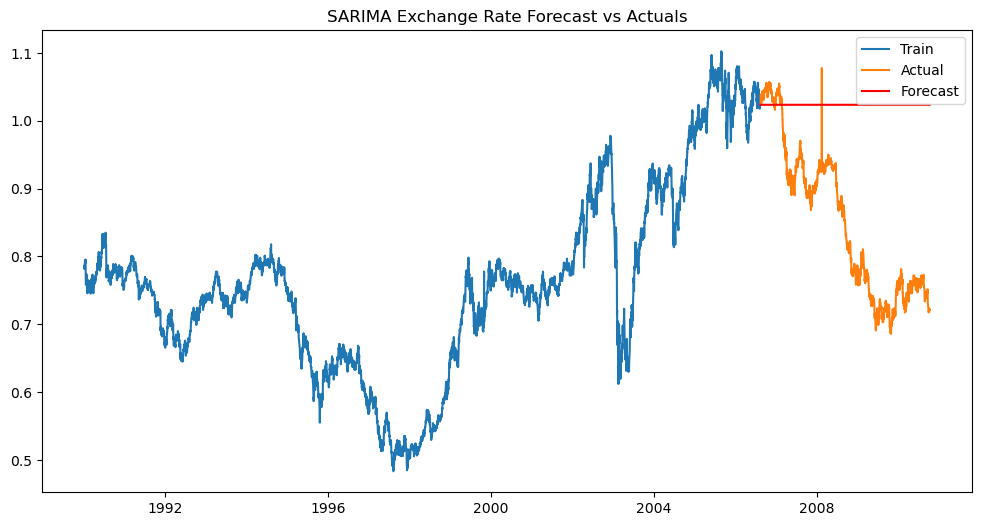

In [51]:
# Visualize Forecast
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_sarima, label='Forecast', color='red')
plt.legend()
plt.title('SARIMA Exchange Rate Forecast vs Actuals')
plt.show()

### Part 3: Evaluation and Comparison

1. **Compute Error Metrics:** Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2. **Model Comparison:** Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3. **Conclusion:** Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

In [64]:
def calculate_metrics(y_true, y_pred):
    """
    Calculates MAE, RMSE, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE calculation function (handling potential zero values in y_true if necessary, but here we assume non-zero)
    def mean_absolute_percentage_error(y_true, y_pred):
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [65]:
 # Evaluate
arima_metrics_arima = calculate_metrics(test, forecast_arima)
print(f"\nARIMA Metrics: {arima_metrics_arima}")
arima_metrics_sarima = calculate_metrics(test, forecast_sarima)
print(f"\nSARIMA Metrics: {arima_metrics_sarima}")




ARIMA Metrics: {'MAE': 0.1777097044912133, 'RMSE': np.float64(0.20543669659669261), 'MAPE': np.float64(22.797970153330347)}

SARIMA Metrics: {'MAE': 0.1777097044912133, 'RMSE': np.float64(0.20543669659669261), 'MAPE': np.float64(22.797970153330347)}


In [66]:
matrix=pd.DataFrame({"Arima":arima_metrics_arima,"Sarima":arima_metrics_sarima})
matrix.T

,MAE,RMSE,MAPE
Arima,0.17771,0.205437,22.79797
Sarima,0.17771,0.205437,22.79797


**Comparison**

|Feature 	|ARIMA	|SARIMA|
|----|----|----|
|Seasonality	|Does not account for seasonal patterns.	|Explicitly models seasonal patterns with additional parameters (P, D, Q, m).|
|Model Complexity	|Generally simpler, with fewer parameters (p, d, q) to estimate.	|More complex due to the addition of seasonal components.|
|Data Requirements	|Can be used with shorter datasets.	|Requires sufficiently long data that captures multiple seasonal cycles for accurate parameter estimation.|
|Forecast Accuracy|	Struggles with data that has strong seasonality, leading to less accurate forecasts in such cases.	|Generally provides more accurate forecasts for data with prominent seasonal fluctuations by accounting for them.|
|When to use	|Use when data has trends/cycles but no obvious, repeating seasonal patterns.	|Use when data exhibits clear and predictable seasonal cycles (e.g., monthly sales with holiday spikes).|

**Advantages and Disadvantages**

* **ARIMA**
  * Advantages
      * Simplicity: Easier to understand, implement, and interpret due to fewer parameters.
      * Efficiency with limited data: Fewer parameters are an advantage when dealing with limited observations.
      * Suitable for non-seasonal data: Effective for capturing trends and short-term dependencies in data that lacks seasonal patterns.
  * Disadvantages
      * Poor performance with seasonality: Fails to capture seasonal effects effectively, leading to less accurate forecasts for seasonal data.
      * Parameter selection challenge: Selecting the optimal p, d, q parameters can require expertise, though automated tools exist (e.g., auto_arima in pmdarima library). 

* **SARIMA**

  * Advantages
    * Superior seasonal modeling: Specifically designed to capture and forecast recurring seasonal patterns effectively.
    * Improved accuracy: Often provides significantly more accurate forecasts for seasonal data compared to ARIMA, as validated by metrics like MAE and RMSE in comparative studies.
    * Well-suited for long-term forecasting: Its ability to model seasonal trends makes it suitable for long-term planning (e.g., supply chain management).
   * Disadvantages
     
     * Increased complexity: More complex model structure and interpretation due to the additional seasonal parameters (P, D, Q, m).
     * Higher data requirements: Needs longer time series data to reliably estimate both non-seasonal and seasonal parameters.
     * Risk of overfitting: The increased number of parameters can lead to overfitting, especially with noisy or limited data.
     * Parameter tuning difficulty: Optimizing the numerous seasonal and non-seasonal parameters can be challenging and requires careful selection using techniques like information criteria (AIC/BIC).

**Key Takeaways from Model Implementation**
* Data Preparation is Crucial: The Date column must be converted to a datetime index in pandas, and the data should be checked for missing values and a constant frequency before modeling.
* Stationarity is Key: Visualizing the data and using statistical tests (like the Augmented Dickey-Fuller test) helps confirm if the data is stationary. Differencing (the 'I' component) is applied until stationarity is achieved
* Parameter Selection: Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are typically used to identify the optimal parameters (p, d, q, P, D, Q, s). The statsmodels library in Python provides the SARIMAX function to fit these models.
* Model Evaluation: Performance is evaluated using metrics like AIC, BIC, MAE, MSE, and RMSE. Lower values for these metrics indicate a better model fit.
* Residual Analysis: Model diagnostics are essential to ensure the residuals are white noise (randomly distributed with no patterns), which indicates a well-fitted model. 

In a real-world scenario with currency exchange rates, the data often exhibits complex, sometimes non-linear, patterns and volatility. While ARIMA/SARIMA models can provide a solid baseline, advanced deep learning models like LSTMs have shown superior forecasting capability for capturing such nuances. 
